# Import Dataset

In [1]:
import os
import pandas as pd
os.getcwd()

'C:\\Users\\Maibrit\\Documents\\Master PCPT\\These\\Python_PyCharm'

# Trying to Correctly Decode my File

In [2]:
#How is my file encoded?
import chardet

with open("threads_hot0203.csv", "rb") as f:
    raw_data = f.read(100000)  # sample
    result = chardet.detect(raw_data)

print(result)

#Apparently, it most likely it utf-8

{'encoding': 'utf-8', 'confidence': 0.8007752, 'language': 'en'}


In [3]:
# Try to fix the encoding
df = pd.read_csv("threads_hot0203.csv", encoding="utf-8", encoding_errors="replace")

In [4]:
# See if there are any bad rows left
print(df["text"].str.contains(r"Ã|â|�", na=False).sum())
# Yes, 15

15


In [5]:
# Now, try something else
from ftfy import fix_text

df["text"] = df["text"].apply(lambda x: fix_text(x) if isinstance(x, str) else x)
df["title"] = df["title"].apply(lambda x: fix_text(x) if isinstance(x, str) else x)


In [6]:
print(df["text"].str.contains(r"Ã|â|�", na=False).sum())
print(df["title"].str.contains(r"Ã|â|�", na=False).sum())
# No more falsely decoded rows

0
0


# Load Dataset

In [7]:
#df = pd.read_csv("threads_hot0203.csv")
#UTF 8 encoding does not seem to work, so try something else

#df = pd.read_csv("threads_hot0203.csv", encoding="latin-1")
#latin-1 encoding works
df.head()
#df.columns
#df.shape

,Unnamed: 0,date_utc,timestamp,title,text,subreddit,comments,url
0,1,2025-12-14,1765741825,Am I too inteligent for life or am i just coping?,"'ve constructed a fake world in my mind, the r...",dpdr,1,https://www.reddit.com/r/dpdr/comments/1pmn69k...
1,2,2025-12-14,1765734691,Childhood depersonalization,Im a 17 female Ive had depersonalization for 1...,dpdr,5,https://www.reddit.com/r/dpdr/comments/1pmk8s1...
2,3,2025-12-14,1765707679,Magnesium glycinate helped,After reading so many people saying it would h...,dpdr,9,https://www.reddit.com/r/dpdr/comments/1pmava7...
3,4,2025-12-14,1765694746,Dream-like state,I think I'm experiencing it again recentlyEver...,dpdr,2,https://www.reddit.com/r/dpdr/comments/1pm7kyw...
4,5,2025-12-14,1765713507,Difficulty To Process Information Properly?,"Hi there,Dissociation makes it incredibly hard...",dpdr,6,https://www.reddit.com/r/dpdr/comments/1pmcez0...


# Look at Dataset

Search for Missing Entries

In [8]:
df["title"].isna().sum()
df["text"].isna().sum()

np.int64(99)

# Prepare Dataset

In [9]:
# Combine title and text into one document
df["document"] = (
    df["title"].fillna("").astype(str).str.strip() + " " +
    df["text"].fillna("").astype(str).str.strip()
).str.strip()
# I now created a new row called "document" where text and title are combined

In [10]:
# Some decoding errors occur when combining "title" and "text", so let's try fixing that
df["document"] = df["document"].apply(lambda x: fix_text(x) if isinstance(x, str) else x)

In [11]:
print(df["document"].str.contains(r"Ã|â|�", na=False).sum())
#No falsely decoded entries in the "document" column

0


In [12]:
mask = df["document"].str.contains(r"Ã|â|�", na=False)
for idx, row in df[mask].iterrows():
    print(f"--- Row {idx} ---")
    print(row["document"])
    print()

In [13]:
# Where are the afflicted rows?
mask = df["document"].str.contains(r"Ã|â|�", na=False)
df[mask][["title", "text", "document"]]

,title,text,document


In [14]:
# Show the rows more clearly
print(df.loc[30]["document"])

Official r/DPDR Discord [https://discord.gg/nFT9G6WzbQ](https://discord.gg/nFT9G6WzbQ)


In [15]:
print(df["document"].str.contains(r"Ã|â|�", na=False).sum())

0


Remove deleted/removed posts

In [16]:
# Are there removed/deleted posts?
df["document"].str.lower().isin(["[removed]", "[deleted]"]).sum()
# No, but let's keep in the code anyways

np.int64(0)

In [17]:
# Remove empty or deleted posts
df = df[
    df["document"].notna() &
    ~df["document"].str.strip().str.lower().isin(["[deleted]", "[removed]", ""])
]

In [18]:
# Were all empty/deleted posts removed?
df["document"].str.lower().isin(["[removed]", "[deleted]"]).sum()

np.int64(0)

Remove URLs

In [19]:
# Are there hyperlinks or URLs in the dataset?
url_rows = df[
    df["document"].str.contains(
        r"http|https|www",
        case=False,
        na=False,
        regex=True
    )
]

url_rows[["document"]]

,document
30,Official r/DPDR Discord [https://discord.gg/nF...
31,I just created a DPDR discord group Hi everyon...
40,Official r/DPDR Discord [https://discord.gg/nF...
67,"Recovery, y'all. **TL;DR:** Struggled with sev..."
82,"Weekly Symptom-Check Thread (Please ask all ""D..."
140,Official r/DPDR Discord [https://discord.gg/nF...
188,Unreal booklet There is this charity called Un...
216,Did he suffer from dpdr and found a cure? [htt...
221,Weekly Symptom & Is This DPDR? Check-In Thread...
262,Official r/DPDR Discord [https://discord.gg/nF...


In [20]:
# Are there URLs left?
url_mask = df["document"].str.contains(r"http\S+|www\S+", case=False, na=False)

df_with_urls = df[url_mask]

print(f"Number of rows with URLs: {url_mask.sum()}")
df_with_urls.head()

#Yes, there are. Let's remove them.

Number of rows with URLs: 49


,Unnamed: 0,date_utc,timestamp,title,text,subreddit,comments,url,document
30,31,2025-12-12,1765566098,Official r/DPDR Discord,[https://discord.gg/nFT9G6WzbQ](https://discor...,dpdr,0,https://www.reddit.com/r/dpdr/comments/1pl05ao...,Official r/DPDR Discord [https://discord.gg/nF...
31,32,2025-12-12,1765560703,I just created a DPDR discord group,"Hi everyone, I've just created a discord group...",dpdr,1,https://www.reddit.com/r/dpdr/comments/1pkxusf...,I just created a DPDR discord group Hi everyon...
40,41,2025-12-12,1765499330,Official r/DPDR Discord,[https://discord.gg/nFT9G6WzbQ](https://discor...,dpdr,0,https://www.reddit.com/r/dpdr/comments/1pkdpts...,Official r/DPDR Discord [https://discord.gg/nF...
67,68,2025-12-09,1765309383,"Recovery, y'all.",**TL;DR:** Struggled with severe DPDR and exis...,dpdr,3,https://www.reddit.com/r/dpdr/comments/1pih33i...,"Recovery, y'all. **TL;DR:** Struggled with sev..."
82,83,2025-12-08,1765206053,"Weekly Symptom-Check Thread (Please ask all ""D...",*Please don't forget to check out the [Officia...,dpdr,1,https://www.reddit.com/r/dpdr/comments/1phejt9...,"Weekly Symptom-Check Thread (Please ask all ""D..."


In [21]:
# Remove URLs (http, https, and www)
df["document"] = df["document"].str.replace(
    r"\[.*?\]\(http\S+?\)|http\S+|www\S+",
    "",
    regex=True
)
len(df)
# This code makes the URLs into empty space. The empty space is removed in a later step

998

In [22]:
df[df["document"].str.contains("https", case=False, na=False)]

,Unnamed: 0,date_utc,timestamp,title,text,subreddit,comments,url,document


In [23]:
print(df.loc[783, "document"])

Back to back Déjà vus There was a night where I had a Déjà vu, of a Déjà vu of a Déjà vu& many more déjà vus and I had what felt like a, (existential awakening) in that instance. The next day, I forgot everything that happened. Im just remembering this now since Im in a better state of mind. My mind truly is my worst enemy.


Remove Duplicates

In [24]:
df = df.drop_duplicates(subset=["document"])
#How many rows are left?
len(df)

974

Remove other things that may confuse BERTopic

In [25]:
# Remove mentions
df["document"] = df["document"].str.replace(r"@\S+", "", regex=True)

# Remove hashtag sign but keep the word
#df["document"] = df["document"].str.replace(r"#(\w+)", r"\1", regex=True)

# Don't remove punctuation
#df["document"] = df["document"].str.replace(r"[^\w\s]", " ", regex=True)

# Dont't make everything lowercase
#df["document"] = df["document"].str.lower()

# Remove extra whitespace
df["document"] = df["document"].str.replace(r"\s+", " ", regex=True).str.strip()

# Remove empty rows again after cleaning
df = df[df["document"] != ""]

In [26]:
# Look at what happened
df["document"].head(10).tolist()
#Still looks good

["Am I too inteligent for life or am i just coping? 've constructed a fake world in my mind, the real world became a second priority. My fake world is unexplainable to others, but it offers me comfort while the real world seems like hell, even though my life isn't especially traumatic, I'm just extremely lonely, with not a single soul to talk to besides my therapist of one month (this experience of somebody listending to me has been extremely validating, and I'm able to understand myself a little bit more).I've been sufferering from a derealization so bad that I didn't even think people were real, even my parents whom I avoided. They all just seemed like NPC and i couldn't comprehend the idea that they also have thoughts and their own life.I don't know whether I'm just too smart for life or it's the fact that I've been neglected emotionally by parents (idk if its real, found out this week on reddit, but it explains why I've always wanted to leave home).Does anybody relate?",
 'Childhoo

In [27]:
len(df)

974

# Excluding Posts with Few Words

Let's take a look at the distribution of words per post

In [28]:
# Create a column that can count how many words are there per post
df["word_count"] = df["document"].str.split().str.len()

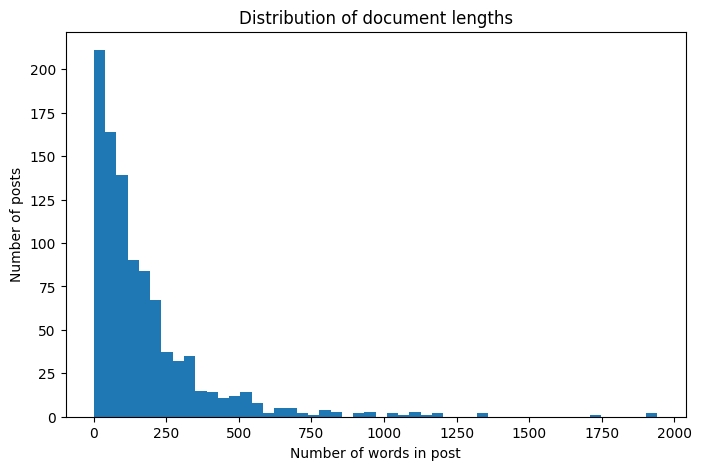

In [29]:
# Histogram of the length of posts (i.e. how many words do posts have?
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["word_count"], bins=50)
plt.xlabel("Number of words in post")
plt.ylabel("Number of posts")
plt.title("Distribution of document lengths")
plt.show()

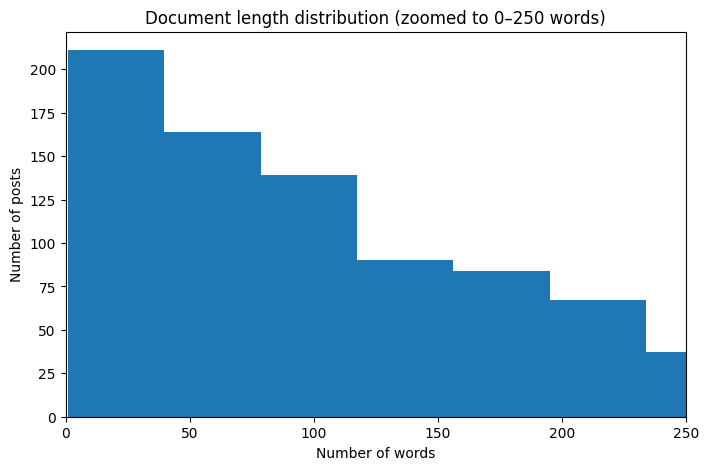

In [30]:
# Most posts seem to be between 1 and 250. Let's zoom in
plt.figure(figsize=(8,5))
plt.hist(df["word_count"], bins=50)
plt.xlim(0,250)
plt.xlabel("Number of words")
plt.ylabel("Number of posts")
plt.title("Document length distribution (zoomed to 0–250 words)")
plt.show()

In [31]:
# What is the minimum number of words per post?
df["word_count"].min()
# Apparently, at least 1 post contains only 1 word. How much value can this post even add to my analyis?

np.int64(1)

In [32]:
# I am thinking of removing posts with fewer than 10 words. Look at which posts there are with fewer than 10 words and if it makes sense to remove them.
# There are some posts with 6 words that make sense to keep (e.g. "It will get better." or "Anyone wanna be friends"). Remove posts with less than 4 words
#df[df["word_count"] < 6][["title", "text", "word_count"]].head(10)
# These are mainly titles without any text to it


df[df["word_count"] == 6][["document", "word_count"]].head(30)

,document,word_count
143,Seeking Support: Experiences With Freeze Mode,6
315,What helped me feel normal again,6
341,Effects of San Pedro on DP/DR?,6
342,Effects of San Pedro on dp/dr,6
565,Fatigue You feel fatigued all day,6
567,High Does anyone feel high 24/7?,6


# Preprocessing

Remove posts with less than 6 words and URLs

In [33]:
# Remove posts with less than 7 words (i.e. 6 or less)
df = df[df["word_count"] >= 7]
# How many rows are left?
len(df)

922

In [34]:
# Does everything still look good?
df[["title","text","document"]].head(3)

,title,text,document
0,Am I too inteligent for life or am i just coping?,"'ve constructed a fake world in my mind, the r...",Am I too inteligent for life or am i just copi...
1,Childhood depersonalization,Im a 17 female Ive had depersonalization for 1...,Childhood depersonalization Im a 17 female Ive...
2,Magnesium glycinate helped,After reading so many people saying it would h...,Magnesium glycinate helped After reading so ma...


In [35]:
# Describe the dataset


print(df["document"].str.contains(r"Ã|â|�", na=False).sum())
df["word_count"].describe()

0


count     922.000000
mean      185.183297
std       216.866171
min         7.000000
25%        56.000000
50%       117.000000
75%       224.000000
max      1942.000000
Name: word_count, dtype: float64

In [36]:
#Final length:
print("Final length df:")
len(df)

Final length df:


922

Download the df

In [37]:
# Download the dataset (it is not possible to download lists apparently) -> Refer to this document later on, but convert it into a list
#df.to_csv("dpdr_preprocessed.csv", index=False)
#df.to_csv("dpdr_preprocessed_final.csv", index=False)


In [38]:
print("Everything worked (hopefully)")

Everything worked (hopefully)


Finished this step!!